In [ ]:
import pandas as pd
import sys
sys.path.append('..')
from utils.database_process import create_individual_list, run_foldx, rename_mutant_pdbs
import os
from tqdm import tqdm
# jupyter notebook tqdm setup
tqdm.pandas()

In [2]:
mu_df = pd.read_pickle('./saved_tables/cleaned_mutant_complex_table.pkl')

In [3]:
mu_df

,Mutations,Source Data Set,PDB_ori,KD(M),Ligand Chains,Receptor Chains,wt_paths,affinity,PDB,new_pdb_name,mut_paths
0,A_M14A,SKEMPI_v2.0,1A22,9.000000e-10,A,B,PDB/SKEMPI_v2.0/1A22.pdb,12.334439,1A22,1a22_1,PDB/mutant_pdbs/1a22/1a22_1.pdb
1,A_H18A,SKEMPI_v2.0,1A22,3.960000e-10,A,B,PDB/SKEMPI_v2.0/1A22.pdb,12.820613,1A22,1a22_2,PDB/mutant_pdbs/1a22/1a22_2.pdb
2,A_H21A,SKEMPI_v2.0,1A22,1.170000e-09,A,B,PDB/SKEMPI_v2.0/1A22.pdb,12.179070,1A22,1a22_3,PDB/mutant_pdbs/1a22/1a22_3.pdb
3,A_Q22A,SKEMPI_v2.0,1A22,6.210000e-10,A,B,PDB/SKEMPI_v2.0/1A22.pdb,12.554178,1A22,1a22_4,PDB/mutant_pdbs/1a22/1a22_4.pdb
4,A_F25A,SKEMPI_v2.0,1A22,4.230000e-10,A,B,PDB/SKEMPI_v2.0/1A22.pdb,12.781553,1A22,1a22_5,PDB/mutant_pdbs/1a22/1a22_5.pdb
...,...,...,...,...,...,...,...,...,...,...,...
6712,"A_D13G, B_S10A",SKEMPI_v2.0,5XCO,9.900000e-07,A,B,PDB/SKEMPI_v2.0/5XCO.pdb,8.187316,5XCO,5xco_25,PDB/mutant_pdbs/5xco/5xco_25.pdb
6713,"A_D13G, B_Y11A",SKEMPI_v2.0,5XCO,1.000000e-06,A,B,PDB/SKEMPI_v2.0/5XCO.pdb,8.181364,5XCO,5xco_26,PDB/mutant_pdbs/5xco/5xco_26.pdb
6714,"A_D13G, B_D12A",SKEMPI_v2.0,5XCO,1.000000e-06,A,B,PDB/SKEMPI_v2.0/5XCO.pdb,8.181364,5XCO,5xco_27,PDB/mutant_pdbs/5xco/5xco_27.pdb
6715,"A_D13G, B_P13A",SKEMPI_v2.0,5XCO,3.200000e-07,A,B,PDB/SKEMPI_v2.0/5XCO.pdb,8.856122,5XCO,5xco_28,PDB/mutant_pdbs/5xco/5xco_28.pdb


In [4]:
mu_df.to_csv('./saved_tables/mutant_table.csv', index=False)

In [5]:
mu_df['affinity'].min(), mu_df['affinity'].max()

(np.float64(1.8988195434458073), np.float64(21.406497853317127))

In [ ]:
def process_pdb_mutations(pdb_subset_df, foldx_executable, working_dir_root, rotabase_location=None, base_pdb_dir='../../GraPPI_data/'):
    # Get PDB code (assuming all rows have same PDB)
    pdb_code = pdb_subset_df['PDB'].iloc[0]
    pdb_lower = pdb_code.lower()
    
    # Construct path to wild type PDB
    wt_pdb_path = os.path.join(base_pdb_dir, f"{pdb_subset_df['wt_paths'].iloc[0]}")
    working_dir = os.path.join(working_dir_root, pdb_lower)
    if not os.path.exists(wt_pdb_path):
        print(f"Error: Wild type PDB not found at {wt_pdb_path}")
        return
    
    # Create output directory
    os.makedirs(working_dir, exist_ok=True)
    
    # Create individual_list file
    mutations_list = pdb_subset_df['Mutations'].tolist()
    individual_list_path = os.path.join(working_dir, 'individual_list.txt')
    create_individual_list(mutations_list, individual_list_path)
    
    # Run FoldX
    run_foldx(wt_pdb_path, individual_list_path, foldx_executable, working_dir, rotabase_location=rotabase_location)
    # Rename output files to desired format
    # Note: FoldX output naming may vary, adjust rename_mutant_pdbs accordingly
    #print("\nRenaming mutant structures...")
    #rename_mutant_pdbs(pdb_subset_df, working_dir, True)

# Process all mutants

## Some stats of mutant pdbs

In [5]:
# pdb that have the most mutants
import numpy as np
most_mutants_pdb = mu_df['PDB'].unique()[np.argmax([len(mu_df[mu_df['PDB'] == pdb]) for pdb in mu_df['PDB'].unique()])]
print(max([len(mu_df[mu_df['PDB'] == pdb]) for pdb in mu_df['PDB'].unique()]), most_mutants_pdb, len(mu_df['PDB'].unique()))

296 1AO7 379


In [6]:
mu_df[mu_df['PDB']=='1AO7']

,PDB,Mutations,KD(M),affinity,Ligand Chains,Receptor Chains,wt_paths,filesize
3932,1AO7,D_D26A,1.900000e-05,6.437706,"A, B, C","D, E",PDB/SKEMPI_v2.0/1AO7.pdb,462.611
3933,1AO7,A_E58A,1.080000e-06,8.135789,"A, B, C","D, E",PDB/SKEMPI_v2.0/1AO7.pdb,462.611
3934,1AO7,"A_E58A, D_D26A",1.290000e-05,6.667008,"A, B, C","D, E",PDB/SKEMPI_v2.0/1AO7.pdb,462.611
3935,1AO7,D_R27A,4.880000e-06,7.242662,"A, B, C","D, E",PDB/SKEMPI_v2.0/1AO7.pdb,462.611
3937,1AO7,A_R170A,1.410000e-06,7.977895,"A, B, C","D, E",PDB/SKEMPI_v2.0/1AO7.pdb,462.611
...,...,...,...,...,...,...,...,...
12607,1AO7,"E_E105H, E_Q106P, E_Y107Q",1.500000e-06,7.945250,"A, C","D, E",PDB/ATLAS/1AO7.pdb,265.522
12608,1AO7,"E_A99M, E_G100S, E_G101A, E_R102Q",2.500000e-09,11.735335,"A, C","D, E",PDB/ATLAS/1AO7.pdb,265.522
12609,1AO7,A_K66A,2.000000e-04,5.046309,"A, C","D, E",PDB/ATLAS/1AO7.pdb,265.522
12610,1AO7,C_Y5F,2.700000e-06,7.596995,"A, C","D, E",PDB/ATLAS/1AO7.pdb,265.522


Text(0, 0.5, 'Frequency')

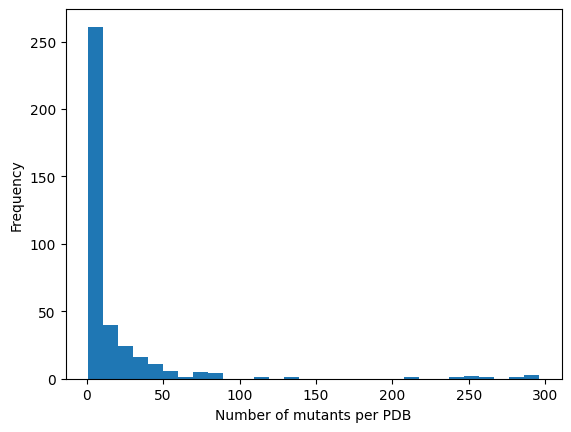

In [7]:
nu_muts = [len(mu_df[mu_df['PDB'] == pdb]) for pdb in mu_df['PDB'].unique()]
import matplotlib.pyplot as plt
plt.hist(nu_muts, bins=30)
plt.xlabel('Number of mutants per PDB')
plt.ylabel('Frequency')

PDB                                                             1EMV
Mutations          A_D24E, A_D58R, A_D59E, A_E30D, A_E40R, A_E56D...
KD(M)                                                            0.0
affinity                                                   10.680338
Ligand Chains                                                      A
Receptor Chains                                                    B
wt_paths                                    PDB/SKEMPI_v2.0/1EMV.pdb
filesize                                                     149.696
Name: 794, dtype: object
27


Text(0, 0.5, 'Frequency')

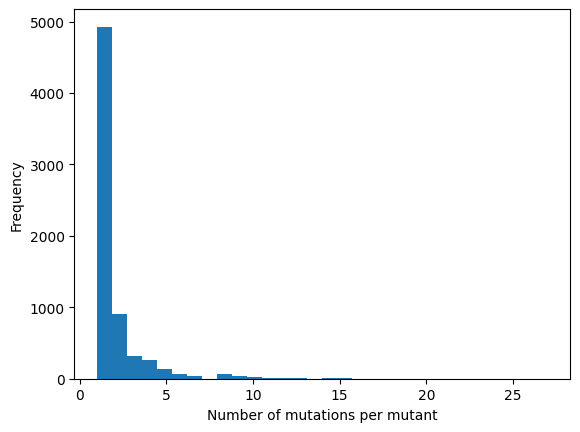

In [8]:
nu_muts_meanwhile = [len(muts.split(',')) for muts in mu_df['Mutations']]
print(mu_df.iloc[np.argmax(nu_muts_meanwhile)])
print(max(nu_muts_meanwhile))
plt.hist(nu_muts_meanwhile, bins=30)
plt.xlabel('Number of mutations per mutant')
plt.ylabel('Frequency')